### Weather-Electricity Demand Relationships: A comparative Analysis of Linear Regression and Machine-Learning Approaches in Texas.

In [2]:
# Importing the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import matplotlib.dates as mdates
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [3]:
# Reading the dataset
file_path = "EnergyWeatherDataset.xlsx"  
df = pd.read_excel(file_path)

In [4]:
# Converting 'datetime' column to pandas datetime
df['datetime'] = pd.to_datetime(df['datetime'], dayfirst=True)
df = df.set_index('datetime')  # optional but recommended for resampling

In [5]:
# Checking dataframe
df.head() 

,COAST,EAST,FWEST,NORTH,NCENT,SOUTH,SCENT,WEST,Total,COAST_TEMP,...,SOUTH_WS,SOUTH_PRCP,SCENT_TEMP,SCENT_RH,SCENT_WS,SCENT_PRCP,FWEST_TEMP,FWEST_RH,FWEST_WS,FWEST_PRCP
datetime,,,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,10156.086100,1389.019650,2117.036400,918.525200,14045.144600,3661.591600,6915.819180,1504.437620,40707.660350,4.76,...,4.00,9.17,2.00,87.99,4.30,2.87,-2.47,94.21,7.35,0.06
2015-01-01 01:00:00,9844.200268,1350.784678,2078.060021,901.770195,13640.024978,3607.904503,6731.301663,1470.814721,39624.861027,4.76,...,4.02,8.00,1.93,88.39,4.10,3.00,-2.26,96.41,6.29,0.05
2015-01-01 02:00:00,9653.456269,1333.434943,2057.993265,890.150373,13425.121941,3609.619438,6602.935629,1440.832944,39013.544802,4.75,...,4.04,8.47,1.87,88.72,3.91,3.18,-1.91,96.84,5.74,0.03
2015-01-01 03:00:00,9502.299659,1323.908498,2039.019542,880.926639,13286.070909,3573.158363,6530.663273,1430.495044,38566.541927,4.70,...,3.97,8.58,1.87,88.90,3.82,3.54,-1.77,98.36,5.50,0.02
2015-01-01 04:00:00,9474.478036,1325.951405,2027.431312,883.990576,13310.892590,3538.420320,6503.367925,1423.806348,38488.338511,4.57,...,3.71,6.94,1.90,88.91,3.80,3.90,-1.65,98.16,5.36,0.03


In [6]:
#Checking dataframe information
df.info() 

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 87672 entries, 2015-01-01 00:00:00 to 2024-12-31 23:00:00
Data columns (total 41 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   COAST       87671 non-null  float64
 1   EAST        87671 non-null  float64
 2   FWEST       87671 non-null  float64
 3   NORTH       87671 non-null  float64
 4   NCENT       87671 non-null  float64
 5   SOUTH       87671 non-null  float64
 6   SCENT       87671 non-null  float64
 7   WEST        87671 non-null  float64
 8   Total       87671 non-null  float64
 9   COAST_TEMP  87672 non-null  float64
 10  COAST_RH    87672 non-null  float64
 11  COAST_WS    87672 non-null  float64
 12  COAST_PRCP  87672 non-null  float64
 13  EAST_TEMP   87672 non-null  float64
 14  EAST_RH     87672 non-null  float64
 15  EAST_WS     87672 non-null  float64
 16  EAST_PRCP   87672 non-null  float64
 17  WEST_TEMP   87672 non-null  float64
 18  WEST_RH     87672 non-null  flo

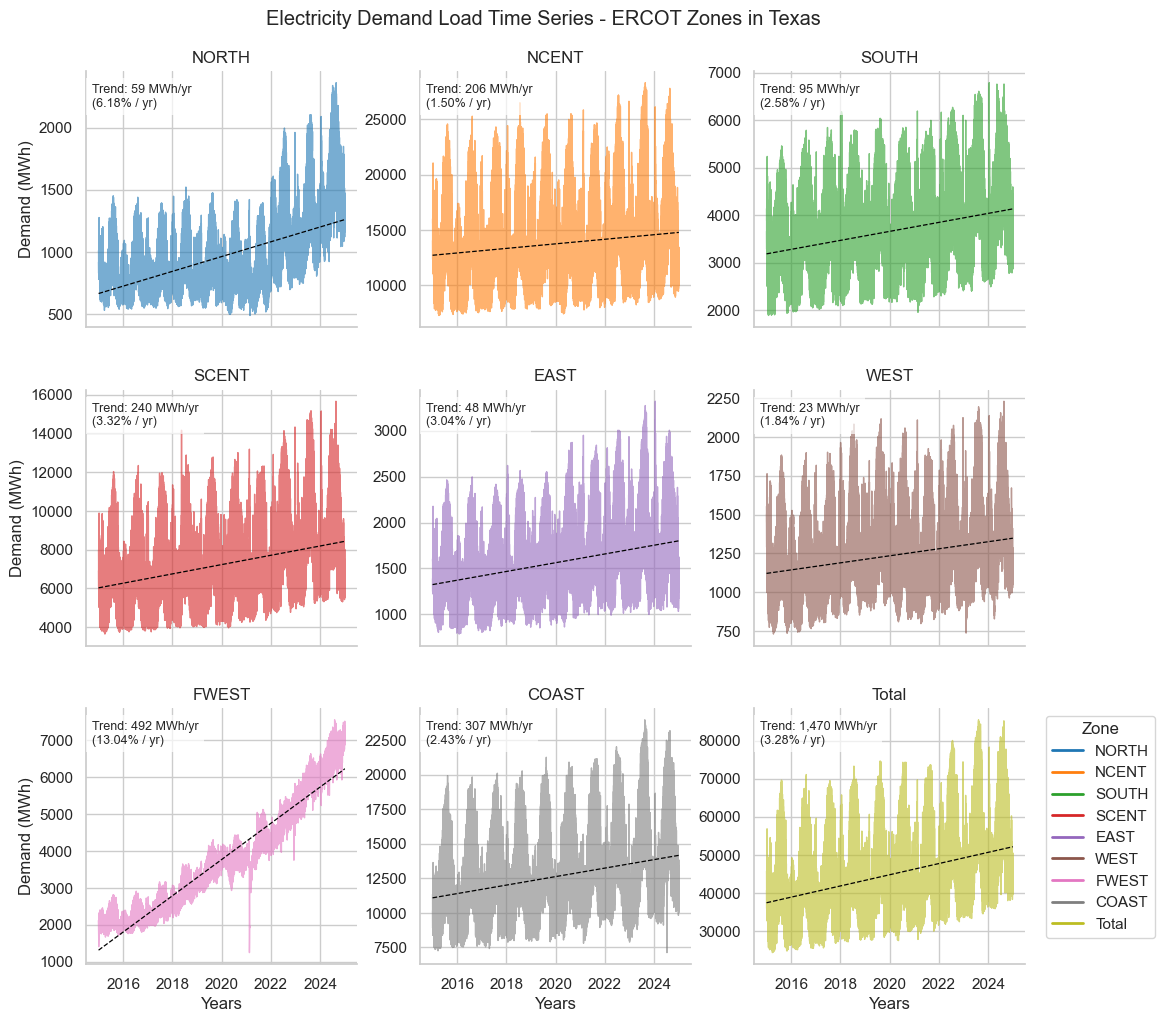

In [7]:
# Plotting time series of the demand load for each zone to check the data
sns.set_theme(style="whitegrid")

# Defining the demand columns
zones = ['NORTH', 'NCENT', 'SOUTH', 'SCENT', 'EAST', 'WEST', 'FWEST', 'COAST', 'Total']
df_long = df.reset_index().melt(
    id_vars='datetime',
    value_vars=zones,
    var_name='Zone',
    value_name='Load'
)

# Using a distinct color palette
palette = sns.color_palette("tab10", len(zones)) #"tab10"
zone_colors = dict(zip(zones, palette))

# Creating a FacetGrid
g = sns.FacetGrid(df_long, col="Zone", col_wrap=3, sharey=False, height=3.4)

# Looping manually and ploting each zone with its own color
for ax, zone in zip(g.axes.flatten(), zones):
    subset = df_long[df_long["Zone"] == zone].copy()

    subset["datetime"] = pd.to_datetime(subset["datetime"], errors="coerce")
    subset = subset.dropna(subset=["datetime", "Load"]).sort_values("datetime")

    # Plot raw series
    ax.plot(
        subset["datetime"],
        subset["Load"],
        color=zone_colors[zone],
        linewidth=1,
        alpha=0.6
    )

    # Time in days since start
    x = (subset["datetime"] - subset["datetime"].min()).dt.days.to_numpy(float)
    y = subset["Load"].to_numpy(float)

    # Fit linear trend
    coef = np.polyfit(x, y, 1)
    slope_day = coef[0]
    slope_year = slope_day * 365  # MW/year

    # Percent trend
    mean_load = y.mean()
    pct_trend = (slope_year / mean_load) * 100  # % per year

    trend = np.poly1d(coef)

    # Plot trend
    ax.plot(
        subset["datetime"],
        trend(x),
        color="black",
        linestyle="--",
        linewidth=0.9
    )

    # Annotation: MW/year + %/year
    ax.text(
        0.02, 0.95,
        f"Trend: {slope_year:,.0f} MWh/yr\n({pct_trend:.2f}% / yr)",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

    ax.set_title(zone)
    

# Titles
g.set_axis_labels("Years", "Demand (MWh)")
plt.subplots_adjust(top=0.92)
g.fig.suptitle("Electricity Demand Load Time Series - ERCOT Zones in Texas")

# Adding legend
handles = []
for zone in zones:
    handles.append(plt.Line2D([0], [0], color=zone_colors[zone], linewidth=2))

plt.legend(handles, zones, title="Zone",
           bbox_to_anchor=(1.05, 1),
           loc='upper left')

# Saving the plot
g.savefig("ercot_zones.jpg", dpi=300)

plt.show()

In [8]:
# Checking if the datetime index is properly ordered before creating daily variables.
df.index.is_monotonic_increasing

True

# Creating Daily Summaries from the dataset

In [9]:
# Creating the daily total load from the hourly load per zone
# Identifing all zone-level load columns
zone_cols = ['NORTH', 'NCENT', 'SOUTH', 'SCENT', 'EAST', 'WEST', 'FWEST', 'COAST', 'Total']

# Creating daily total load per zone
df_daily = df[zone_cols].resample('D').sum()

# Renaming columns to daily names
df_daily = df_daily.rename(columns={col: f"{col}_Daily_Load_MW" for col in zone_cols})

df_daily.head()

,NORTH_Daily_Load_MW,NCENT_Daily_Load_MW,SOUTH_Daily_Load_MW,SCENT_Daily_Load_MW,EAST_Daily_Load_MW,WEST_Daily_Load_MW,FWEST_Daily_Load_MW,COAST_Daily_Load_MW,Total_Daily_Load_MW
datetime,,,,,,,,,
2015-01-01,22800.843764,353454.825306,91672.924020,175265.796109,35366.299886,35750.777821,49573.570520,249279.652142,1.013165e+06
2015-01-02,22344.116717,346361.845154,89334.309215,171316.838254,35427.171021,33920.608102,45466.931129,241843.802797,9.860156e+05
2015-01-03,20120.944490,302420.250804,78844.142286,146613.769096,33210.056777,27812.854391,37216.822347,227509.946968,8.737488e+05
2015-01-04,22525.678779,341491.895349,76948.650460,151440.442950,36433.864303,28754.145196,38713.680133,236923.970583,9.332323e+05
2015-01-05,23751.515201,375887.507630,87418.685821,177033.082819,41066.824803,31555.622067,41577.247963,275407.059507,1.053698e+06


In [10]:
# Computing daily mean temperature per zone
# Identifying zone temperature columns
temp_cols = ['NORTH_TEMP', 'NCENT_TEMP', 'SOUTH_TEMP', 'SCENT_TEMP',
             'EAST_TEMP', 'WEST_TEMP', 'FWEST_TEMP', 'COAST_TEMP']

# Daily mean temperature per zone
df_daily_tmean = df[temp_cols].resample('D').mean()

# Renaming columns
df_daily_tmean = df_daily_tmean.rename(columns={col: f"{col}_Daily_Tmean" for col in temp_cols})

df_daily_tmean.head()

,NORTH_TEMP_Daily_Tmean,NCENT_TEMP_Daily_Tmean,SOUTH_TEMP_Daily_Tmean,SCENT_TEMP_Daily_Tmean,EAST_TEMP_Daily_Tmean,WEST_TEMP_Daily_Tmean,FWEST_TEMP_Daily_Tmean,COAST_TEMP_Daily_Tmean
datetime,,,,,,,,
2015-01-01,0.599167,1.471667,5.751250,3.345417,2.672500,-2.838750,0.847083,5.625833
2015-01-02,1.991667,3.143333,6.705833,4.566667,4.814167,-1.456667,0.876250,9.215000
2015-01-03,4.410000,5.701250,8.510833,7.713750,6.206667,-1.269583,1.025417,9.580417
2015-01-04,-0.931250,1.279167,8.537500,5.643750,0.105417,-2.895000,2.906667,5.295417
2015-01-05,-0.472500,0.477917,5.742500,3.163750,-0.461250,0.591250,4.541250,3.420000


In [11]:
# Computing daily Cooling Degree Days (CDD) and Heating Degree Days (HDD) per zone with base temperature = 18.3°C 
# Temperature columns per zone
temp_cols = [
    'NORTH_TEMP', 'NCENT_TEMP', 'SOUTH_TEMP', 'SCENT_TEMP',
    'EAST_TEMP', 'WEST_TEMP', 'FWEST_TEMP', 'COAST_TEMP'
]

# Base temperature for HDD/CDD
base = 18.3  # base temperature

# Computing hourly HDD and CDD for each zone
for col in temp_cols:
    df[f"{col}_CDD18"] = (df[col] - base).clip(lower=0)
    df[f"{col}_HDD18"] = (base - df[col]).clip(lower=0)

# Identifying new degree-day columns
cdd_cols = [f"{col}_CDD18" for col in temp_cols]
hdd_cols = [f"{col}_HDD18" for col in temp_cols]

# Daily sums (degree days are summed, not averaged)
df_daily_dd = df[cdd_cols + hdd_cols].resample('D').sum()

# Renaming to daily version
df_daily_dd = df_daily_dd.rename(columns={
    col: f"{col}_Daily" for col in df_daily_dd.columns
})

df_daily_dd.head()

,NORTH_TEMP_CDD18_Daily,NCENT_TEMP_CDD18_Daily,SOUTH_TEMP_CDD18_Daily,SCENT_TEMP_CDD18_Daily,EAST_TEMP_CDD18_Daily,WEST_TEMP_CDD18_Daily,FWEST_TEMP_CDD18_Daily,COAST_TEMP_CDD18_Daily,NORTH_TEMP_HDD18_Daily,NCENT_TEMP_HDD18_Daily,SOUTH_TEMP_HDD18_Daily,SCENT_TEMP_HDD18_Daily,EAST_TEMP_HDD18_Daily,WEST_TEMP_HDD18_Daily,FWEST_TEMP_HDD18_Daily,COAST_TEMP_HDD18_Daily
datetime,,,,,,,,,,,,,,,,
2015-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,424.82,403.88,301.17,358.91,375.06,507.33,418.87,304.18
2015-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,391.40,363.76,278.26,329.60,323.66,474.16,418.17,218.04
2015-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,333.36,302.37,234.94,254.07,290.24,469.67,414.59,209.27
2015-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,461.55,408.50,234.30,303.75,436.67,508.68,369.44,312.11
2015-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,450.54,427.73,301.38,363.27,450.27,425.01,330.21,357.12


In [12]:
# Creating daily mean humidity and windspeed that will be used later for machine learning (ML) 

# Humidity columns
humidity_cols = [
    'NORTH_RH', 'NCENT_RH', 'SOUTH_RH', 'SCENT_RH',
    'EAST_RH', 'WEST_RH', 'FWEST_RH', 'COAST_RH'
]

# Wind speed columns
wind_cols = [
    'NORTH_WS', 'NCENT_WS', 'SOUTH_WS', 'SCENT_WS',
    'EAST_WS', 'WEST_WS', 'FWEST_WS', 'COAST_WS'
]

# Creating daily averages
df_daily_humidity = df[humidity_cols].resample('D').mean()
df_daily_wind = df[wind_cols].resample('D').mean()

# Renaming columns
df_daily_humidity = df_daily_humidity.rename(columns={col: f"{col}_Daily" for col in humidity_cols})
df_daily_wind = df_daily_wind.rename(columns={col: f"{col}_Daily" for col in wind_cols})

df_daily_humidity.head(), df_daily_wind.head()

(            NORTH_RH_Daily  NCENT_RH_Daily  SOUTH_RH_Daily  SCENT_RH_Daily  \
 datetime                                                                     
 2015-01-01       89.129583       90.179167       83.861250       88.416250   
 2015-01-02       92.795833       92.537083       86.816250       91.512083   
 2015-01-03       82.493750       78.415000       76.534583       71.537500   
 2015-01-04       71.159583       67.872500       67.807083       61.709167   
 2015-01-05       66.897083       63.777083       64.356667       64.615417   
 
             EAST_RH_Daily  WEST_RH_Daily  FWEST_RH_Daily  COAST_RH_Daily  
 datetime                                                                  
 2015-01-01      90.976250      85.304583       84.451250       91.847083  
 2015-01-02      94.392917      88.766667       82.167917       94.222917  
 2015-01-03      87.648333      84.035833       62.136667       88.356667  
 2015-01-04      73.716667      76.905000       57.987083       7

In [13]:
# Creating daily precipitation summaries per zone
prcp_cols = ['NORTH_PRCP', 'NCENT_PRCP', 'SOUTH_PRCP', 'SCENT_PRCP', 'EAST_PRCP', 'WEST_PRCP', 'FWEST_PRCP', 'COAST_PRCP']

# Creating daily total precipitation per zone
df_daily_prcp = df[prcp_cols].resample('D').sum()

# Renaming columns to daily names
df_daily_prcp = df_daily_prcp.rename(columns={col: f"{col}_Daily_Prcp" for col in prcp_cols})

df_daily_prcp.head()

,NORTH_PRCP_Daily_Prcp,NCENT_PRCP_Daily_Prcp,SOUTH_PRCP_Daily_Prcp,SCENT_PRCP_Daily_Prcp,EAST_PRCP_Daily_Prcp,WEST_PRCP_Daily_Prcp,FWEST_PRCP_Daily_Prcp,COAST_PRCP_Daily_Prcp
datetime,,,,,,,,
2015-01-01,203.37,135.27,55.99,55.79,495.79,20.64,0.50,182.03
2015-01-02,254.65,196.13,32.12,192.19,481.97,482.77,18.01,294.39
2015-01-03,195.72,170.27,17.55,12.60,353.75,74.53,1.15,335.18
2015-01-04,0.49,0.00,0.00,0.00,0.04,0.24,0.03,0.48
2015-01-05,0.03,0.00,0.00,0.00,5.73,1.74,0.00,0.00


In [14]:
# Now, the following variables have been created for each zone:
# - Daily load per zone: df_daily
# - Daily Tmean per zone: df_daily_mean
# - Daily HDD/CDD per zone df_daily_mean
# - Daily relative humidity per zone: df_daily_humidity
# - Daily wind speed per zone: df_daily_wind
# - Daily precipitation per zone: df_daily_prcp

# Joining all the Daily Summaries Created into a Single Dataset

In [15]:
# Joining the five tables into one dataset
dataframe_daily = (
    df_daily
    .join(df_daily_tmean)
    .join(df_daily_dd)
    .join(df_daily_humidity)
    .join(df_daily_wind)
    .join(df_daily_prcp)
)

dataframe_daily.head()

,NORTH_Daily_Load_MW,NCENT_Daily_Load_MW,SOUTH_Daily_Load_MW,SCENT_Daily_Load_MW,EAST_Daily_Load_MW,WEST_Daily_Load_MW,FWEST_Daily_Load_MW,COAST_Daily_Load_MW,Total_Daily_Load_MW,NORTH_TEMP_Daily_Tmean,...,FWEST_WS_Daily,COAST_WS_Daily,NORTH_PRCP_Daily_Prcp,NCENT_PRCP_Daily_Prcp,SOUTH_PRCP_Daily_Prcp,SCENT_PRCP_Daily_Prcp,EAST_PRCP_Daily_Prcp,WEST_PRCP_Daily_Prcp,FWEST_PRCP_Daily_Prcp,COAST_PRCP_Daily_Prcp
datetime,,,,,,,,,,,,,,,,,,,,,
2015-01-01,22800.843764,353454.825306,91672.924020,175265.796109,35366.299886,35750.777821,49573.570520,249279.652142,1.013165e+06,0.599167,...,3.781250,2.990417,203.37,135.27,55.99,55.79,495.79,20.64,0.50,182.03
2015-01-02,22344.116717,346361.845154,89334.309215,171316.838254,35427.171021,33920.608102,45466.931129,241843.802797,9.860156e+05,1.991667,...,4.391667,2.174583,254.65,196.13,32.12,192.19,481.97,482.77,18.01,294.39
2015-01-03,20120.944490,302420.250804,78844.142286,146613.769096,33210.056777,27812.854391,37216.822347,227509.946968,8.737488e+05,4.410000,...,5.902083,2.360833,195.72,170.27,17.55,12.60,353.75,74.53,1.15,335.18
2015-01-04,22525.678779,341491.895349,76948.650460,151440.442950,36433.864303,28754.145196,38713.680133,236923.970583,9.332323e+05,-0.931250,...,2.595417,4.664167,0.49,0.00,0.00,0.00,0.04,0.24,0.03,0.48
2015-01-05,23751.515201,375887.507630,87418.685821,177033.082819,41066.824803,31555.622067,41577.247963,275407.059507,1.053698e+06,-0.472500,...,1.934583,2.305417,0.03,0.00,0.00,0.00,5.73,1.74,0.00,0.00


In [16]:
# Creating calendar controls; this is necessary for the baselines and ML models because electricity demand depends ont the calendar day, not only weather
dataframe_daily['month'] = dataframe_daily.index.month
dataframe_daily['weekday'] = dataframe_daily.index.weekday  # 0=Mon, 6=Sun
dataframe_daily['year'] = dataframe_daily.index.year

# Linear time trend
dataframe_daily['trend'] = range(len(dataframe_daily))

dataframe_daily.head()

,NORTH_Daily_Load_MW,NCENT_Daily_Load_MW,SOUTH_Daily_Load_MW,SCENT_Daily_Load_MW,EAST_Daily_Load_MW,WEST_Daily_Load_MW,FWEST_Daily_Load_MW,COAST_Daily_Load_MW,Total_Daily_Load_MW,NORTH_TEMP_Daily_Tmean,...,SOUTH_PRCP_Daily_Prcp,SCENT_PRCP_Daily_Prcp,EAST_PRCP_Daily_Prcp,WEST_PRCP_Daily_Prcp,FWEST_PRCP_Daily_Prcp,COAST_PRCP_Daily_Prcp,month,weekday,year,trend
datetime,,,,,,,,,,,,,,,,,,,,,
2015-01-01,22800.843764,353454.825306,91672.924020,175265.796109,35366.299886,35750.777821,49573.570520,249279.652142,1.013165e+06,0.599167,...,55.99,55.79,495.79,20.64,0.50,182.03,1,3,2015,0
2015-01-02,22344.116717,346361.845154,89334.309215,171316.838254,35427.171021,33920.608102,45466.931129,241843.802797,9.860156e+05,1.991667,...,32.12,192.19,481.97,482.77,18.01,294.39,1,4,2015,1
2015-01-03,20120.944490,302420.250804,78844.142286,146613.769096,33210.056777,27812.854391,37216.822347,227509.946968,8.737488e+05,4.410000,...,17.55,12.60,353.75,74.53,1.15,335.18,1,5,2015,2
2015-01-04,22525.678779,341491.895349,76948.650460,151440.442950,36433.864303,28754.145196,38713.680133,236923.970583,9.332323e+05,-0.931250,...,0.00,0.00,0.04,0.24,0.03,0.48,1,6,2015,3
2015-01-05,23751.515201,375887.507630,87418.685821,177033.082819,41066.824803,31555.622067,41577.247963,275407.059507,1.053698e+06,-0.472500,...,0.00,0.00,5.73,1.74,0.00,0.00,1,0,2015,4


In [17]:
# Saving the dataset to Excel
dataframe_daily.to_excel("full_daily_dataset.xlsx")

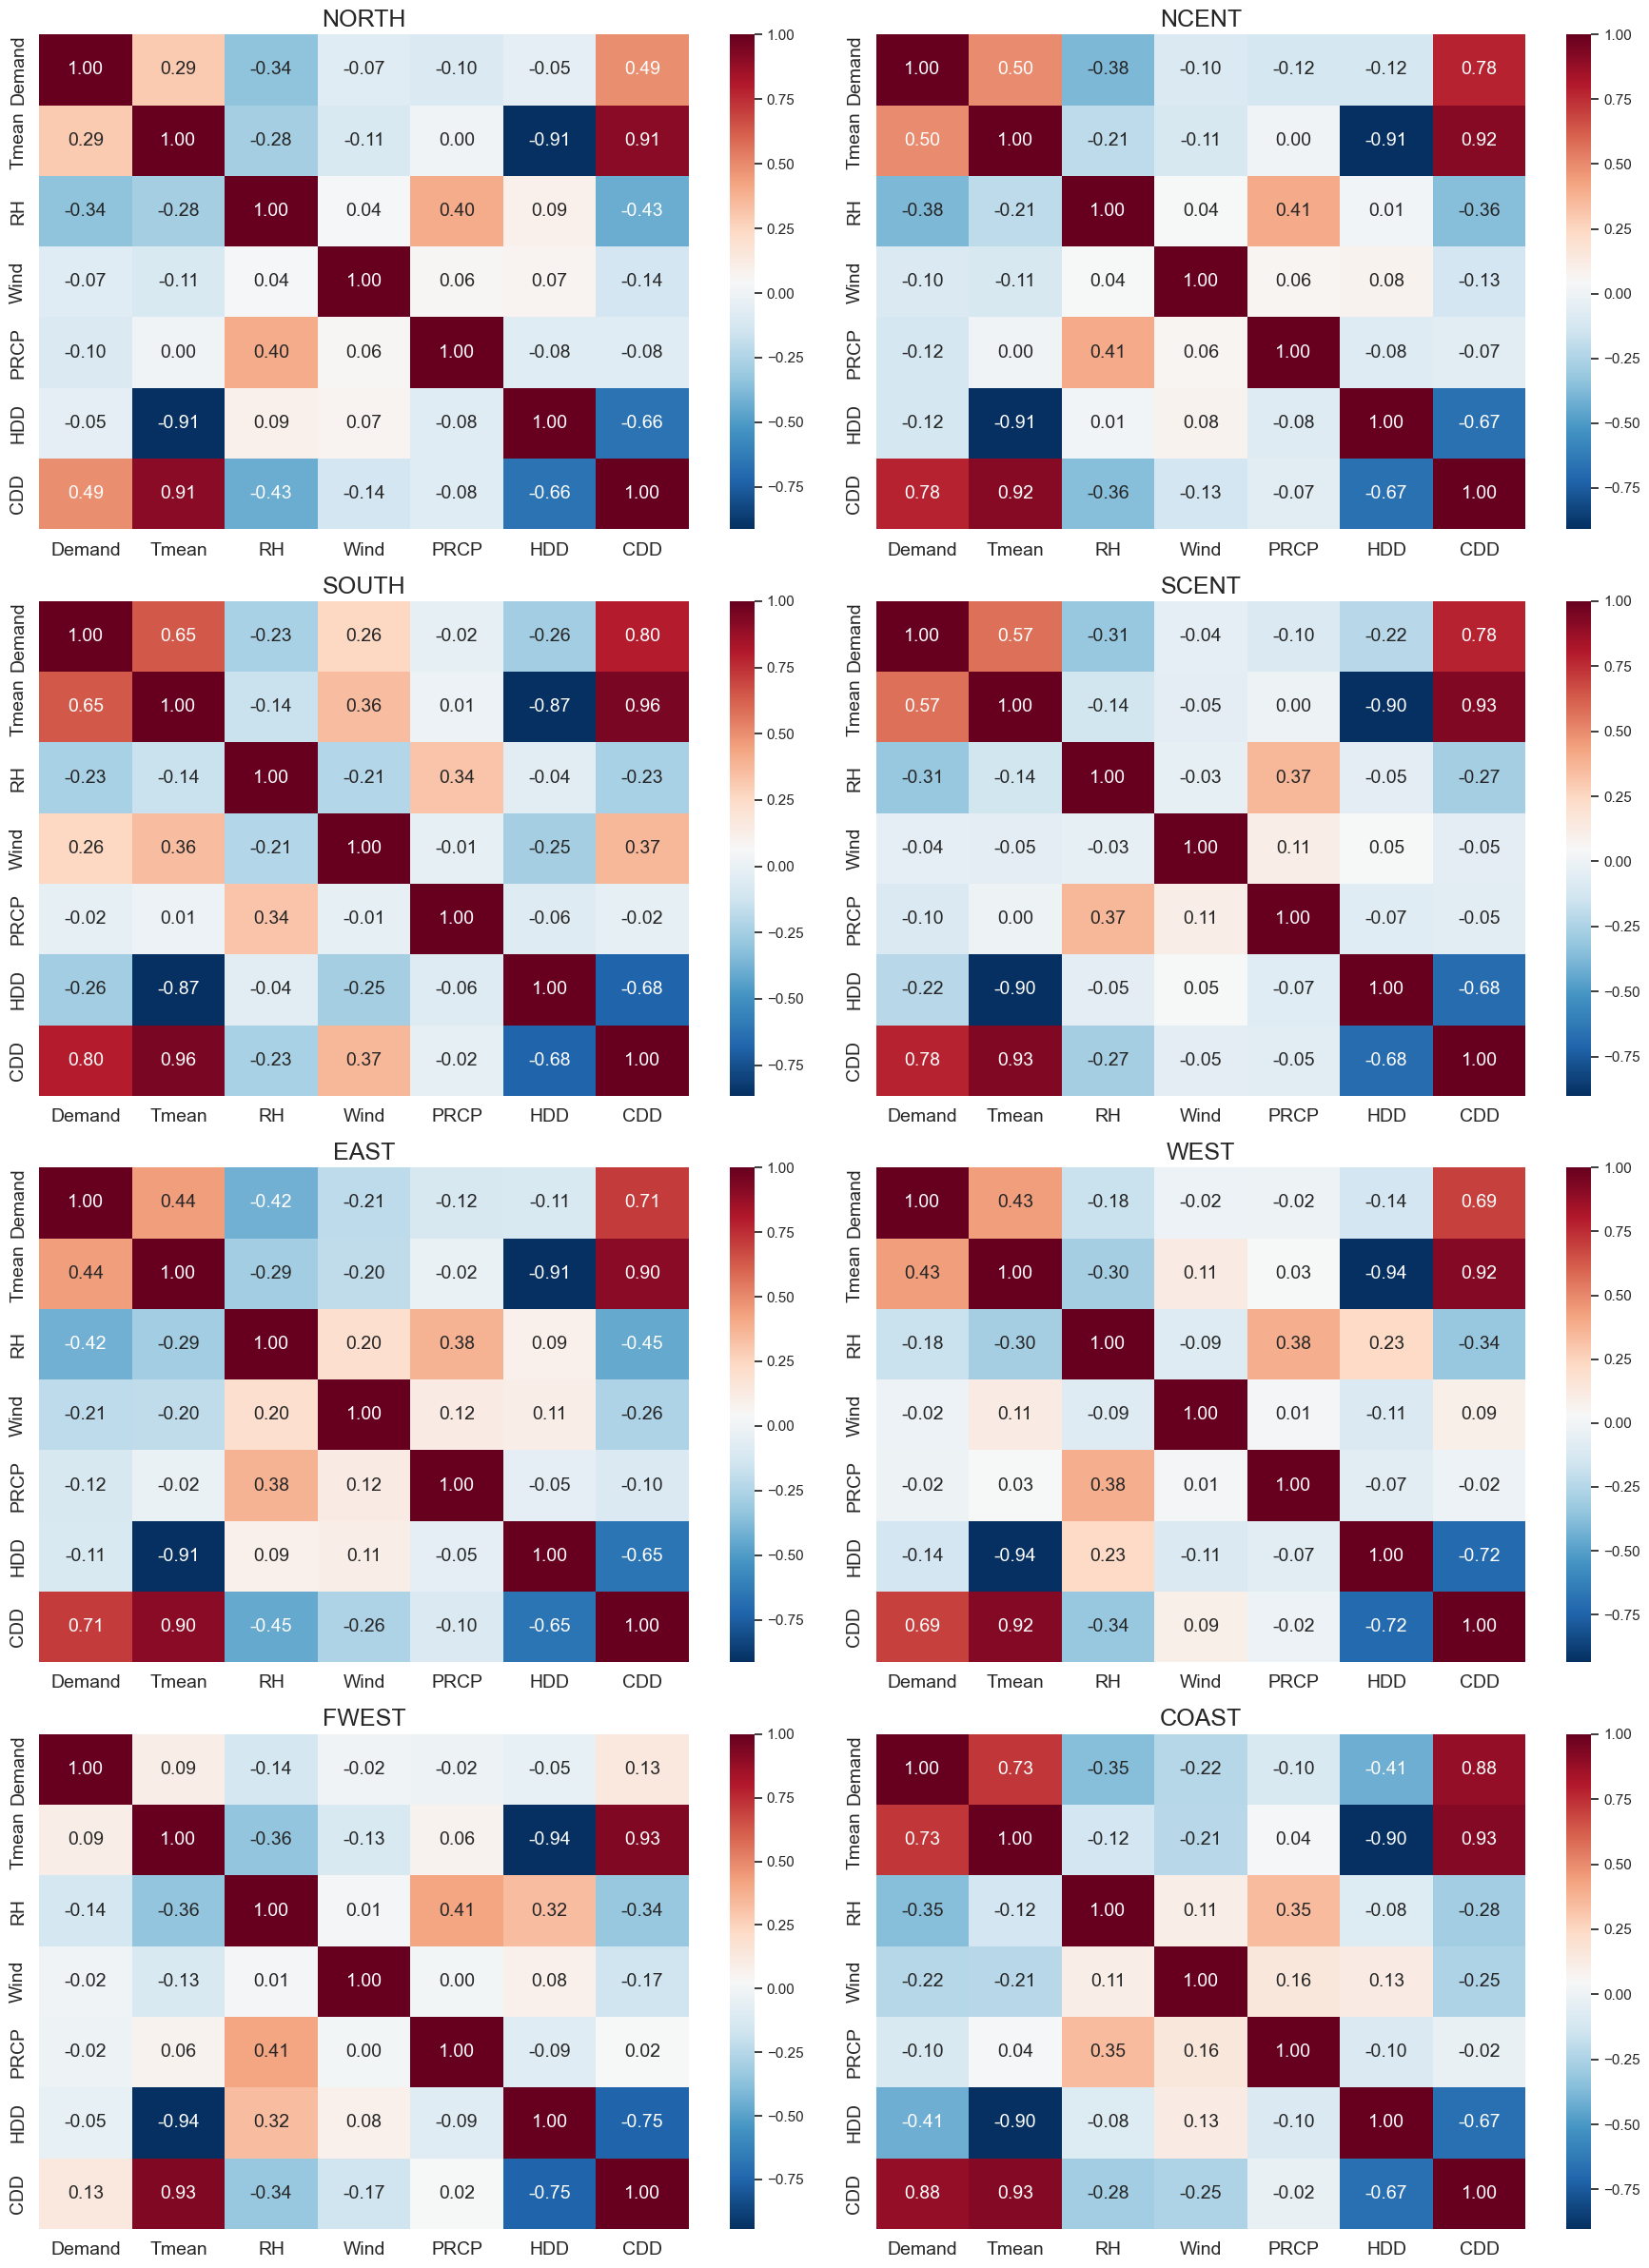

In [18]:
# Plotting correlation plots for the weather parameters and demand load
zones = ['NORTH', 'NCENT', 'SOUTH', 'SCENT', 'EAST', 'WEST', 'FWEST', 'COAST']

def col(zone, var):
    if var == 'Load':
        return f"{zone}_Daily_Load_MW"
    if var == 'Tmean':
        return f"{zone}_TEMP_Daily_Tmean"
    if var == 'RH':
        return f"{zone}_RH_Daily"
    if var == 'Wind':
        return f"{zone}_WS_Daily"
    if var == 'PRCP':
        return f"{zone}_PRCP_Daily_Prcp"
    if var == 'HDD':
        return f"{zone}_TEMP_HDD18_Daily"
    if var == 'CDD':
        return f"{zone}_TEMP_CDD18_Daily"

corplot, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()

for i, z in enumerate(zones):
    dfz = dataframe_daily[[col(z,'Load'),
                     col(z,'Tmean'),
                     col(z,'RH'),
                     col(z,'Wind'),
                     col(z,'PRCP'),
                     col(z,'HDD'),
                     col(z,'CDD')]].copy()

    dfz.columns = ['Demand','Tmean', "RH", "Wind", "PRCP", 'HDD','CDD']

    sns.heatmap(dfz.corr(), annot=True, fmt='.2f', cmap='RdBu_r', annot_kws={"size": 14}, ax=axes[i])
    # Increase axis label font size (x and y axis tick labels)
    axes[i].tick_params(axis='both', labelsize=14)
    
    # Zone title
    axes[i].set_title(f"{z}", fontsize=18)

plt.tight_layout()
corplot.savefig("zonal_correlation_heatmaps.png", dpi=300, bbox_inches='tight')
plt.show()

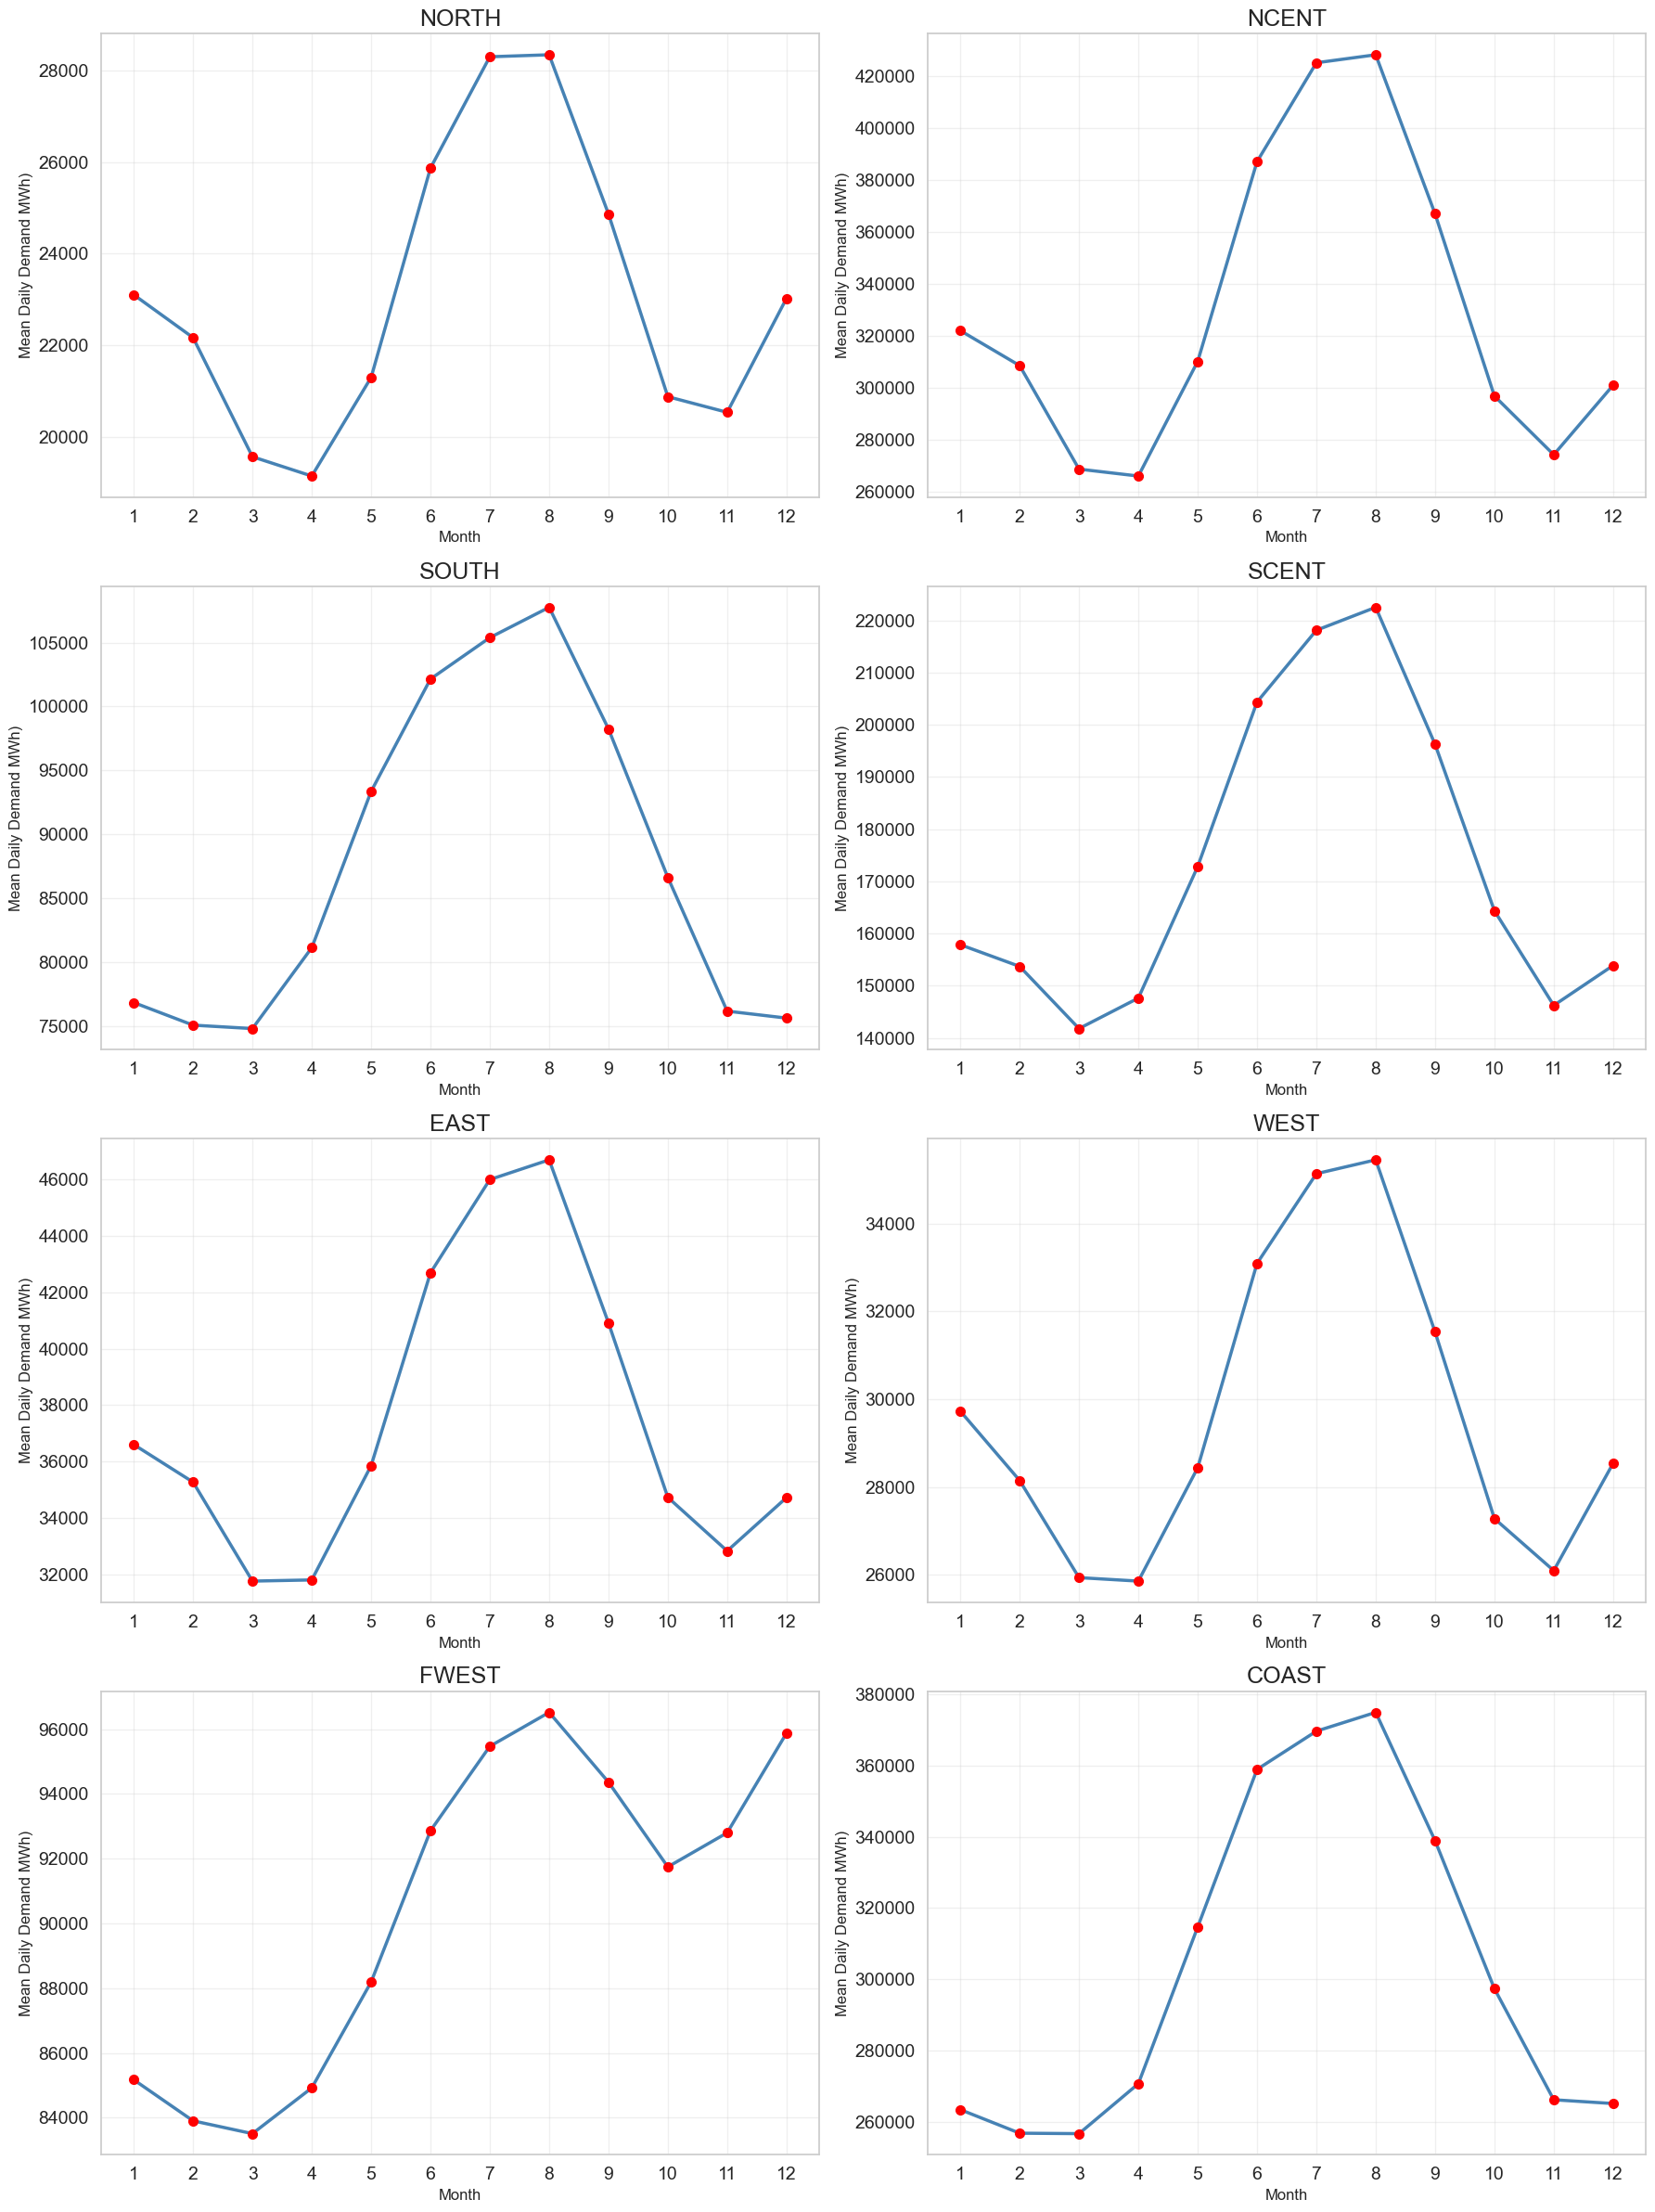

In [19]:
# Creating seasonal plot

def col(zone):
    return f"{zone}_Daily_Load_MW"

# Compute monthly averages
monthly = dataframe_daily.groupby('month').mean(numeric_only=True) # pulls all days relevant to a month into a bucket for that month; 
# Also takes the mean of all daily loads inside each monthly bucket

seasonal_plot, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()

for i, z in enumerate(zones):
    axes[i].plot(
        monthly.index,
        monthly[col(z)],
        marker='o',
        linewidth=2.5,          # ← thicker line
        markersize=7,           # ← bigger points
        markerfacecolor='red',  # ← red dots
        markeredgecolor='red',  # ← red border
        color='steelblue'       # ← line color
    )

    axes[i].set_title(f"{z}", fontsize=18)
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Mean Daily Demand MWh)")
    axes[i].set_xticks(range(1, 13))
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='both', labelsize=14)

plt.tight_layout()
seasonal_plot.savefig("seasonal_plot.png", dpi=300, bbox_inches='tight')
plt.show()

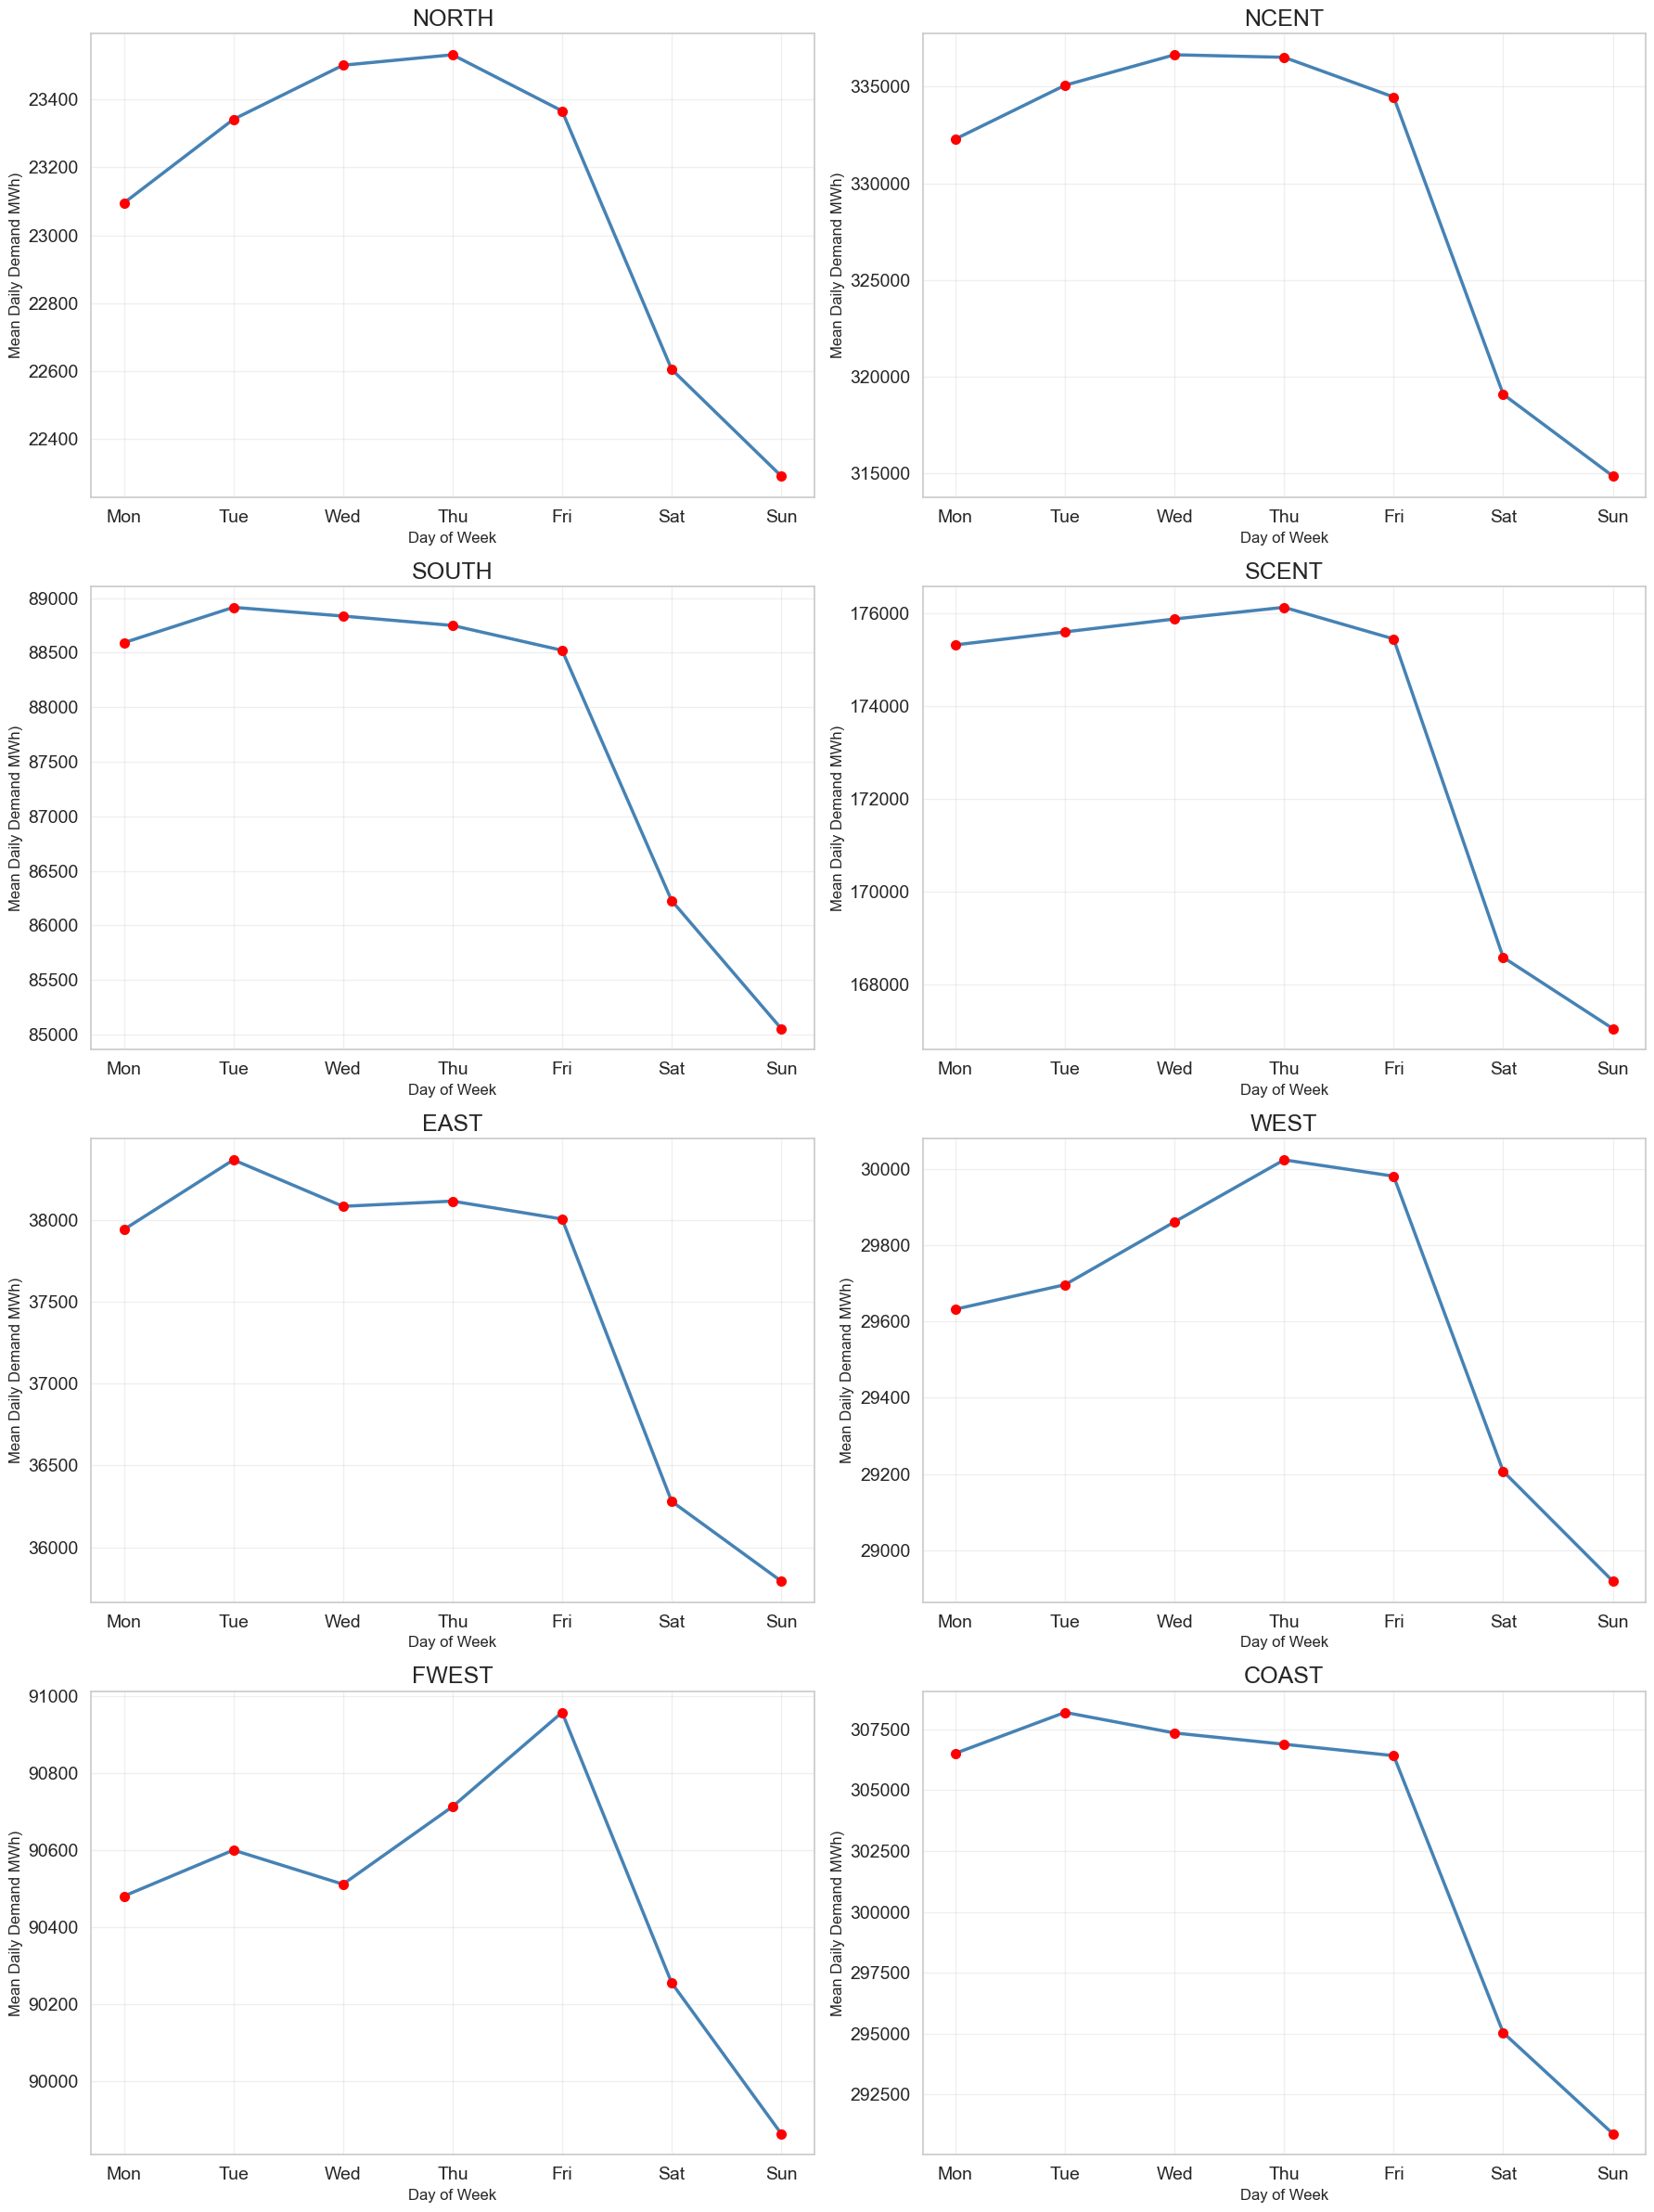

In [20]:
# Weekly (Monday–Sunday) Daily-Profile Plot

def col(zone):
    return f"{zone}_Daily_Load_MW"

# Compute weekday averages (0 = Monday ... 6 = Sunday)
weekly = dataframe_daily.groupby('weekday').mean(numeric_only=True) # pulls all days relevant to a week day into a bucket for that week day
# Also takes the mean of all daily loads inside each weekly bucket

weekday_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

weekly_plot, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()

for i, z in enumerate(zones):
    axes[i].plot(
        weekly.index,
        weekly[col(z)],
        marker='o',
        linewidth=2.5,          # thicker line
        markersize=7,           # larger points
        markerfacecolor='red',  # red markers
        markeredgecolor='red',  # red edges
        color='steelblue'       # line color
    )
    axes[i].set_title(f"{z}", fontsize=18)
    axes[i].set_xlabel("Day of Week")
    axes[i].set_ylabel("Mean Daily Demand MWh)")
    axes[i].set_xticks(range(7))
    axes[i].set_xticklabels(weekday_names)
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='both', labelsize=14)

plt.tight_layout()
weekly_plot.savefig("weekly_profile.png", dpi=300, bbox_inches='tight')
plt.show()

# Baseline 1 Analysis: Tmean as Preditor of Demand Load

In [21]:
# Splitting the dataset: 2015 - 2019 used for training the models, and 2020 to 2024 used for predictions
train = dataframe_daily.loc['2015-01-01':'2019-12-31']
test  = dataframe_daily.loc['2020-01-01':'2024-12-31']

In [22]:
# The baseline regression model for mean temperature (Tmean), as the predictor of demand load
zone_list = ['NORTH', 'NCENT', 'SOUTH', 'SCENT', 'EAST', 'WEST', 'FWEST', 'COAST']

baseline1_results = {}
baseline1_predictions = {}
baseline1_metrics = []

for zone in zone_list:
    
    y_col = f"{zone}_Daily_Load_MW"
    t_col = f"{zone}_TEMP_Daily_Tmean"
    
    # Build zone-specific train/test frames and drop missing rows
    train_zone = train[[y_col, t_col, "month", "weekday", "trend"]].dropna()
    test_zone  = test[[y_col, t_col, "month", "weekday", "trend"]].dropna()
    
    # OLS with calendar controls as categorical fixed effects
    formula = f"{y_col} ~ {t_col} + C(month) + C(weekday) + trend"
    model = smf.ols(formula, data=train_zone).fit()
    
    baseline1_results[zone] = model
    
    # Predict on TEST
    y_test = test_zone[y_col]
    y_pred = model.predict(test_zone)
    baseline1_predictions[zone] = y_pred


    # Compute test metrics
    # RMSE (Root Mean Squared Error): Measures how far, on average, the model’s predictions (y_pred) deviate from the actual observed values (y_test).
    # This is calculated as the square root of the mean of squared errors between predicted and actual loads for each day in the TEST period.
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # MAE (Mean Absolute Error): Measures the average magnitude of daily prediction errors.
    # It takes the absolute difference between actual and predicted values for each day in the TEST period and averages them.
    mae = mean_absolute_error(y_test, y_pred)
    r2  = model.rsquared  # THIS IS TRAIN R² — optional
    # Out-of-sample R²:
    ss_res = np.sum((y_test - y_pred)**2)
    ss_tot = np.sum((y_test - np.mean(y_test))**2)
    r2_test = 1 - ss_res/ss_tot

    baseline1_metrics.append({
        'Zone': zone,
        'RMSE_Test': rmse,
        'MAE_Test': mae,
        'R2_Test': r2_test,
        'R2_Train': model.rsquared
    })

In [23]:
# # Creating metrics table for baseline 1
baseline1_metrics_df = pd.DataFrame(baseline1_metrics).set_index('Zone')
baseline1_metrics_df

,RMSE_Test,MAE_Test,R2_Test,R2_Train
Zone,,,,
NORTH,8228.760224,6329.755066,-0.186282,0.641696
NCENT,44211.992024,35153.693997,0.644319,0.670549
SOUTH,9860.760357,7592.904727,0.660582,0.689611
SCENT,26592.673199,19272.670823,0.552672,0.709618
EAST,5861.053081,4249.350117,0.395307,0.633423
WEST,4813.864320,4165.516313,-0.021987,0.634939
FWEST,21821.535395,16749.822253,0.328264,0.880677
COAST,28819.988804,22049.166344,0.745643,0.788083


# Baseline 2 Analysis: Cooling Degree Days (CDD) and Heating Degree Days (HDD) as the Preditor of Demand Load

In [24]:
# HDD/CDD Model (OLS Model II) with calendar fixed effects
hddcdd_results = {}
hddcdd_predictions = {}
hddcdd_metrics = []

for zone in zone_list:

    y_col  = f"{zone}_Daily_Load_MW"
    hdd_col = f"{zone}_TEMP_HDD18_Daily"
    cdd_col = f"{zone}_TEMP_CDD18_Daily"

    # TRAIN / TEST (drop missing)
    train_zone = train[[y_col, hdd_col, cdd_col, "month", "weekday", "trend"]].dropna()
    test_zone  = test[[y_col, hdd_col, cdd_col, "month", "weekday", "trend"]].dropna()

    # Fit on TRAIN (month & weekday as categorical fixed effects)
    formula = f"{y_col} ~ {hdd_col} + {cdd_col} + C(month) + C(weekday) + trend"
    model = smf.ols(formula, data=train_zone).fit()
    hddcdd_results[zone] = model

    # Predict on TEST 
    y_test = test_zone[y_col]
    y_pred = model.predict(test_zone)
    hddcdd_predictions[zone] = y_pred

    # Compute Test Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    ss_res = np.sum((y_test - y_pred)**2)
    ss_tot = np.sum((y_test - np.mean(y_test))**2)
    r2_test = 1 - ss_res / ss_tot

    hddcdd_metrics.append({
        "Zone": zone,
        "RMSE_Test": rmse,
        "MAE_Test": mae,
        "R2_Test": r2_test,
        "R2_Train": model.rsquared
    })

In [25]:
hddcdd_metrics_df = pd.DataFrame(hddcdd_metrics).set_index('Zone')
hddcdd_metrics_df

,RMSE_Test,MAE_Test,R2_Test,R2_Train
Zone,,,,
NORTH,8147.829011,6146.948036,-0.163062,0.923727
NCENT,20955.590928,15796.738842,0.920094,0.937963
SOUTH,5755.035679,4467.231469,0.884386,0.902951
SCENT,20069.430748,16001.765340,0.745216,0.934638
EAST,4542.535621,3756.506408,0.636771,0.902478
WEST,3908.494193,3581.664861,0.326284,0.873182
FWEST,21813.293357,16747.510558,0.328771,0.897256
COAST,19698.358603,15085.083119,0.881173,0.941937


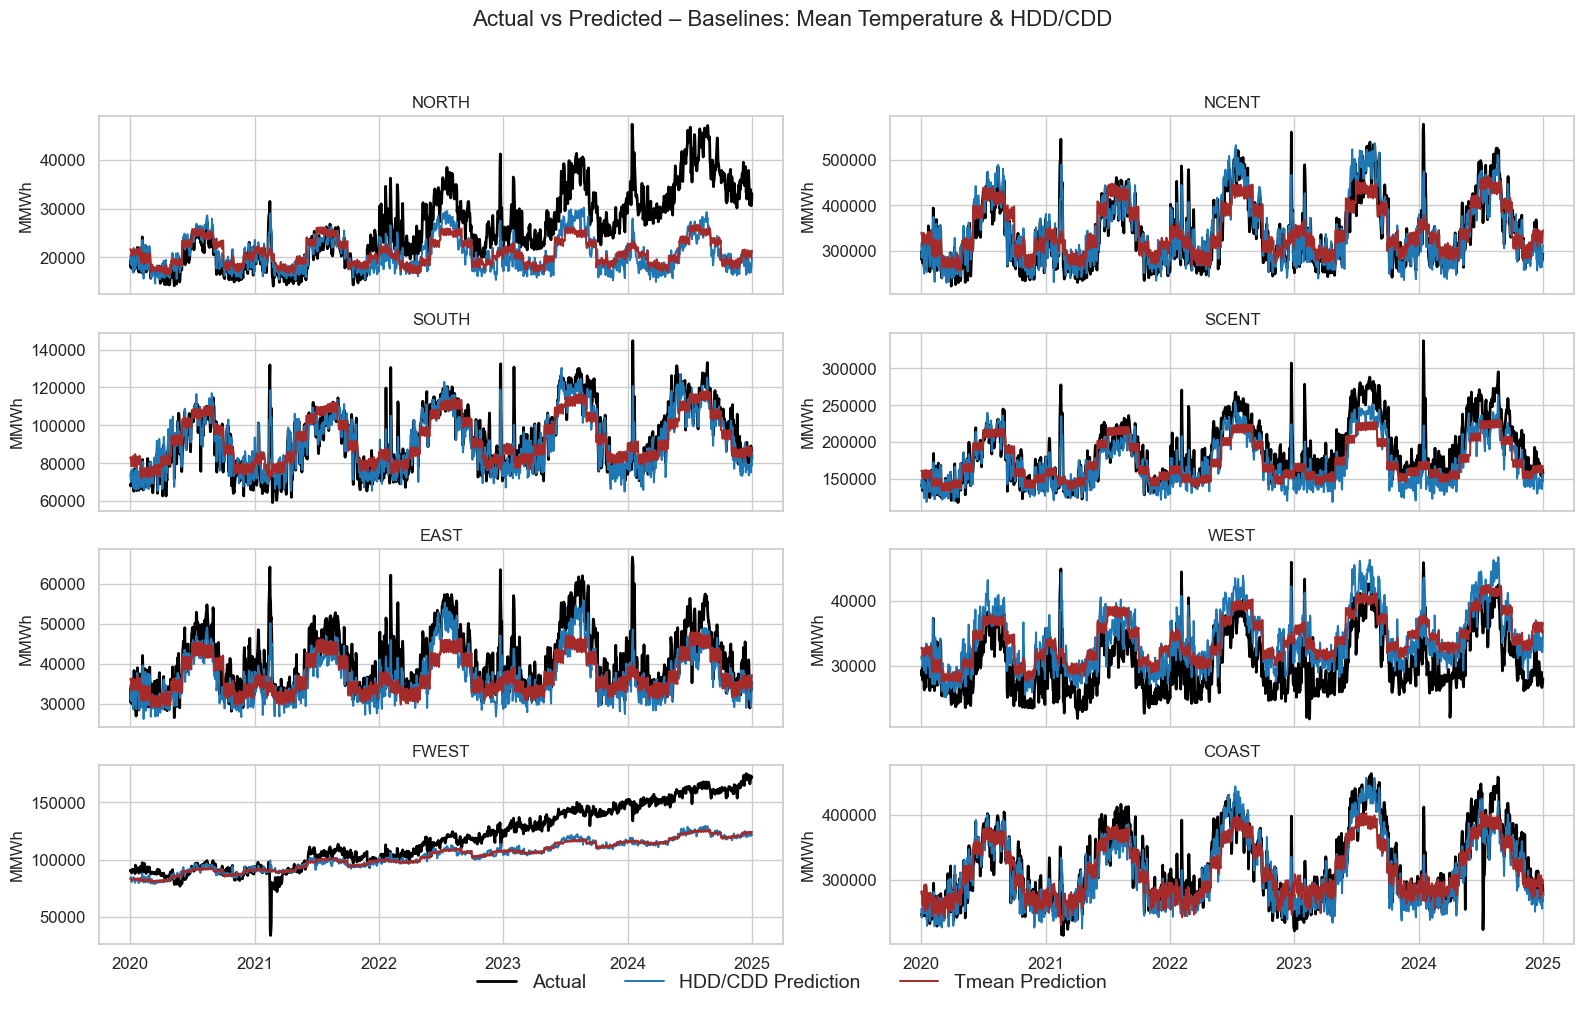

In [26]:
# Plotting the two baseline predictions - 8-Zone Panel
model_title = "Baselines: Mean Temperature & HDD/CDD"

fig, axes = plt.subplots(4, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for i, zone in enumerate(zone_list):

    # Actual load
    axes[i].plot(
        test.index,
        test[f"{zone}_Daily_Load_MW"],
        color="black",
        linewidth=2,
        label="Actual"
    )

    # HDD/CDD predictions
    axes[i].plot(
        test.index,
        hddcdd_predictions[zone],
        color="#1f77b4",
        linewidth=1.4,
        label="HDD/CDD Prediction"
    )
    
         # Tmean predictions
    axes[i].plot(
        test.index,
        baseline1_predictions[zone],
        color="brown",
        linewidth=1.4,
        label="Tmean Prediction"
    )

    axes[i].set_title(zone)
    axes[i].set_ylabel("MMWh")
    axes[i].tick_params(axis='y', labelsize=12)

    # Year ticks on x-axis
    axes[i].xaxis.set_major_locator(mdates.YearLocator())
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axes[i].tick_params(axis='x', labelsize=12)

# Unified legend at bottom 
# Collect handles & labels from last axis
handles, labels = axes[-1].get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=3,
    fontsize=14,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

# Title and layout
plt.suptitle(f"Actual vs Predicted – {model_title}", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("panel_baseline_meanTemp_HDDCDD.png", dpi=300)
plt.show()
plt.close()

# ML 1: Analysis using XGBoost Regressor: CDD/HDD as the predictor of demand load

In [27]:
# Defining the containers for results
ml1_results = {}
ml1_predictions = {}
ml1_metrics = []

from xgboost import XGBRegressor

for zone in zone_list:

    y_col   = f"{zone}_Daily_Load_MW"
    hdd_col = f"{zone}_TEMP_HDD18_Daily"
    cdd_col = f"{zone}_TEMP_CDD18_Daily"

    # TRAIN / TEST DATA (drop missing)
    train_zone = train[[y_col, hdd_col, cdd_col, "month", "weekday", "trend"]].dropna()
    test_zone  = test[[y_col, hdd_col, cdd_col, "month", "weekday", "trend"]].dropna()

    y_train = train_zone[y_col]
    y_test  = test_zone[y_col]

    X_train = train_zone[[hdd_col, cdd_col, "month", "weekday", "trend"]]
    X_test  = test_zone[[hdd_col, cdd_col, "month", "weekday", "trend"]]

    # One-Hot Encoding calendar controls (ML analog of C(month), C(weekday)) ---
    X_train = pd.get_dummies(X_train, columns=["month", "weekday"], drop_first=False)
    X_test  = pd.get_dummies(X_test, columns=["month", "weekday"], drop_first=False)

    # Ensure train/test have identical columns (important!)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    # MODEL
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)
    ml1_results[zone] = model

    # PREDICT
    y_pred = model.predict(X_test)
    ml1_predictions[zone] = y_pred

    # METRICS
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    # Out-of-sample R²
    ss_res = np.sum((y_test - y_pred) ** 2)
    ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
    r2_test = 1 - ss_res / ss_tot

    ml1_metrics.append({
        "Zone": zone,
        "RMSE_Test": rmse,
        "MAE_Test": mae,
        "R2_Test": r2_test
    })

In [28]:
ml1_metrics_df = pd.DataFrame(ml1_metrics).set_index("Zone")
ml1_metrics_df

,RMSE_Test,MAE_Test,R2_Test
Zone,,,
NORTH,8852.371999,6652.218703,-0.372899
NCENT,28321.913445,21518.432228,0.854043
SOUTH,10528.347803,8822.616335,0.613068
SCENT,26465.438100,21952.736704,0.556942
EAST,6872.414897,6186.366373,0.168614
WEST,2201.190324,1742.261833,0.786316
FWEST,42966.317248,34462.364917,-1.604260
COAST,35914.148858,30415.448515,0.605009


# ML 1: Analysis using Random Forest: CDD/HDD as the predictor of demand load

In [29]:
rf1_results = {}
rf1_predictions = {}
rf1_metrics = []

for zone in zone_list:

    y_col   = f"{zone}_Daily_Load_MW"
    hdd_col = f"{zone}_TEMP_HDD18_Daily"
    cdd_col = f"{zone}_TEMP_CDD18_Daily"

    # TRAIN / TEST (drop missing)
    train_zone = train[[y_col, hdd_col, cdd_col, "month", "weekday", "trend"]].dropna()
    test_zone  = test[[y_col, hdd_col, cdd_col, "month", "weekday", "trend"]].dropna()

    y_train = train_zone[y_col]
    y_test  = test_zone[y_col]

    X_train = train_zone[[hdd_col, cdd_col, "month", "weekday", "trend"]]
    X_test  = test_zone[[hdd_col, cdd_col, "month", "weekday", "trend"]]

    # One-Hot Encoding calendar controls (ML analog of C(month), C(weekday)) ---
    X_train = pd.get_dummies(X_train, columns=["month", "weekday"], drop_first=False)
    X_test  = pd.get_dummies(X_test, columns=["month", "weekday"], drop_first=False)

    # Ensure train/test have identical columns
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    # MODEL
    model = RandomForestRegressor(
        n_estimators=400,
        max_depth=12,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    rf1_results[zone] = model

    # PREDICT
    y_pred = model.predict(X_test)
    rf1_predictions[zone] = y_pred

    # METRICS
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    ss_res = np.sum((y_test - y_pred) ** 2)
    ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
    r2_test = 1 - ss_res / ss_tot

    rf1_metrics.append({
        "Zone": zone,
        "RMSE_Test": rmse,
        "MAE_Test": mae,
        "R2_Test": r2_test
    })

In [30]:
rf1_metrics_df = pd.DataFrame(rf1_metrics).set_index("Zone")
rf1_metrics_df

,RMSE_Test,MAE_Test,R2_Test
Zone,,,
NORTH,8457.369745,6374.604307,-0.253112
NCENT,23945.719502,18267.597844,0.895663
SOUTH,8642.083682,7054.867624,0.739294
SCENT,24526.141457,20203.271582,0.619495
EAST,5680.583609,4981.724509,0.431972
WEST,2395.215917,1896.843965,0.746985
FWEST,41444.006178,32605.068070,-1.422990
COAST,30882.218886,25481.848858,0.707940


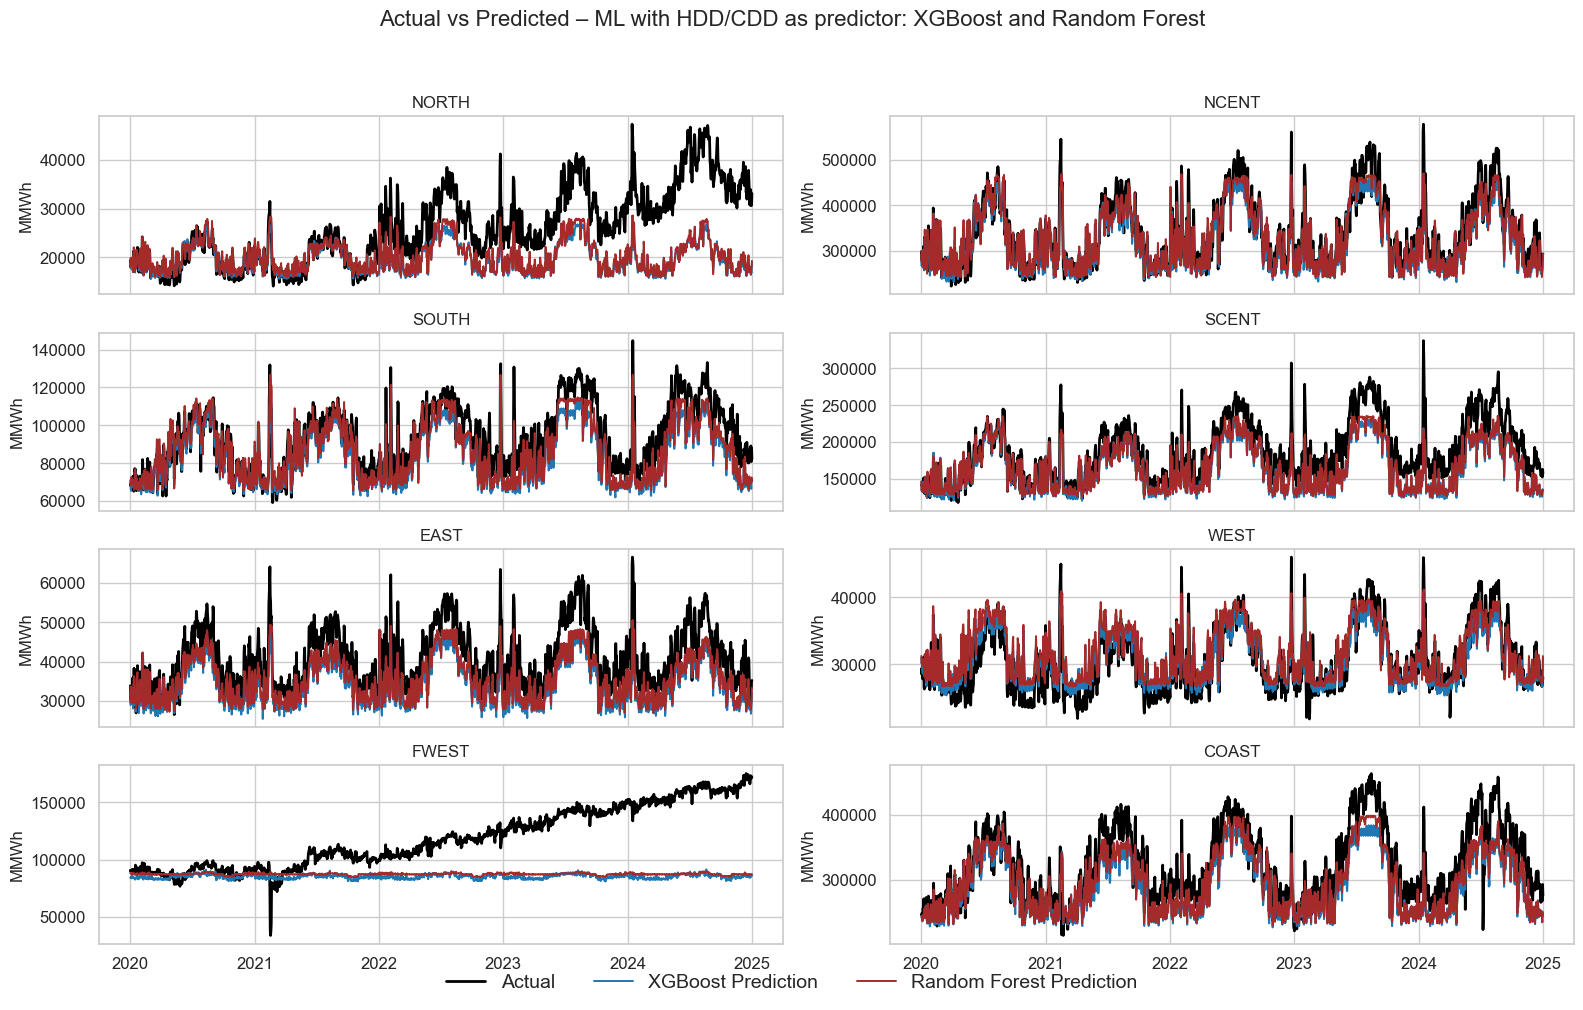

In [31]:
# Plotting ML Set 1: XGBoost and Random Forest - 8-Zone Panel
model_title_2 = "ML with HDD/CDD as predictor: XGBoost and Random Forest"

fig, axes = plt.subplots(4, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for i, zone in enumerate(zone_list):

    # Actual load
    axes[i].plot(
        test.index,
        test[f"{zone}_Daily_Load_MW"],
        color="black",
        linewidth=2,
        label="Actual"
    )

    # XGBoost predictions
    axes[i].plot(
        test.index,
        ml1_predictions[zone],
        color="#1f77b4",
        linewidth=1.4,
        label="XGBoost Prediction"
    )
    
         # Random Forest predictions
    axes[i].plot(
        test.index,
        rf1_predictions[zone],
        color="brown",
        linewidth=1.4,
        label="Random Forest Prediction"
    )

    axes[i].set_title(zone)
    axes[i].set_ylabel("MMWh")
    axes[i].tick_params(axis='y', labelsize=12)

    # Year ticks on x-axis
    axes[i].xaxis.set_major_locator(mdates.YearLocator())
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axes[i].tick_params(axis='x', labelsize=12)

# Unified Legend at Bottom
# Collect handles & labels from last axis
handles, labels = axes[-1].get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=3,
    fontsize=14,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

# Title and layout
plt.suptitle(f"Actual vs Predicted – {model_title_2}", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("ML1_HDDCDD.png", dpi=300)
plt.show()
plt.close()

# ML Model 2 XGBoost Regressor: CDD/HDD, Relative Humidity, Precipitation, and Wind Speed as the predictor of demand load

In [32]:
# Defining the containers for results
ml2_results = {}
ml2_predictions = {}
ml2_metrics = []

In [33]:
for zone in zone_list:

    y_col = f"{zone}_Daily_Load_MW"

    hdd_col  = f"{zone}_TEMP_HDD18_Daily"      # Heating degree days
    cdd_col  = f"{zone}_TEMP_CDD18_Daily"      # Cooling degree days
    rh_col   = f"{zone}_RH_Daily"              # Relative Humidity
    prcp_col = f"{zone}_PRCP_Daily_Prcp"       # Precipitation
    ws_col   = f"{zone}_WS_Daily"              # Wind Speed

    feature_cols = [hdd_col, cdd_col, rh_col, prcp_col, ws_col, "month", "weekday", "trend"]

    # --- TRAIN / TEST (drop missing) ---
    train_zone = train[[y_col] + feature_cols].dropna()
    test_zone  = test[[y_col] + feature_cols].dropna()

    y_train = train_zone[y_col]
    y_test  = test_zone[y_col]

    X_train = train_zone[feature_cols]
    X_test  = test_zone[feature_cols]

    # One-Hot Encoding calendar controls (month, weekday); keep trend numeric
    X_train = pd.get_dummies(X_train, columns=["month", "weekday"], drop_first=False)
    X_test  = pd.get_dummies(X_test, columns=["month", "weekday"], drop_first=False)

    # Ensure train/test have identical columns
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    # MODEL
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)
    ml2_results[zone] = model

    y_pred = model.predict(X_test)
    ml2_predictions[zone] = y_pred

    # METRICS
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    ss_res = np.sum((y_test - y_pred) ** 2)
    ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
    r2_test = 1 - ss_res / ss_tot

    ml2_metrics.append({
        "Zone": zone,
        "RMSE_Test": rmse,
        "MAE_Test": mae,
        "R2_Test": r2_test
    })

In [34]:
ml2_metrics_df = pd.DataFrame(ml2_metrics).set_index("Zone")
ml2_metrics_df

,RMSE_Test,MAE_Test,R2_Test
Zone,,,
NORTH,8941.536857,6703.600459,-0.400695
NCENT,26361.553204,19819.018309,0.873549
SOUTH,10320.888818,8577.443832,0.628167
SCENT,26314.558949,21720.884617,0.561980
EAST,6410.734108,5692.718299,0.276565
WEST,2288.053304,1805.134285,0.769118
FWEST,41972.797767,33299.354587,-1.485215
COAST,33045.047195,27555.057289,0.665598


# ML Model 2 Randorm Forest: CDD/HDD, Relative Humidity, Precipitation, and Wind Speed as the predictor of demand load

In [35]:
# Defining the containers for results
rf2_results = {}
rf2_predictions = {}
rf2_metrics = []

In [36]:
for zone in zone_list:

    y_col = f"{zone}_Daily_Load_MW"

    hdd_col  = f"{zone}_TEMP_HDD18_Daily"      # Heating degree days
    cdd_col  = f"{zone}_TEMP_CDD18_Daily"      # Cooling degree days
    rh_col   = f"{zone}_RH_Daily"              # Relative Humidity
    prcp_col = f"{zone}_PRCP_Daily_Prcp"       # Precipitation
    ws_col   = f"{zone}_WS_Daily"              # Wind Speed

    feature_cols = [hdd_col, cdd_col, rh_col, prcp_col, ws_col, "month", "weekday", "trend"]

    # TRAIN / TEST (drop missing)
    train_zone = train[[y_col] + feature_cols].dropna()
    test_zone  = test[[y_col] + feature_cols].dropna()

    y_train = train_zone[y_col]
    y_test  = test_zone[y_col]

    X_train = train_zone[feature_cols]
    X_test  = test_zone[feature_cols]

    # One-Hot Encoding calendar controls (month, weekday); keep trend numeric
    X_train = pd.get_dummies(X_train, columns=["month", "weekday"], drop_first=False)
    X_test  = pd.get_dummies(X_test, columns=["month", "weekday"], drop_first=False)

    # Ensure train/test have identical columns
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    # MODEL
    model = RandomForestRegressor(
        n_estimators=400,
        max_depth=12,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    rf2_results[zone] = model

    # PREDICT
    y_pred = model.predict(X_test)
    rf2_predictions[zone] = y_pred

    # METRICS
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    ss_res = np.sum((y_test - y_pred) ** 2)
    ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
    r2_test = 1 - ss_res / ss_tot

    rf2_metrics.append({
        "Zone": zone,
        "RMSE_Test": rmse,
        "MAE_Test": mae,
        "R2_Test": r2_test
    })

In [37]:
rf2_metrics_df = pd.DataFrame(rf2_metrics).set_index("Zone")
rf2_metrics_df

,RMSE_Test,MAE_Test,R2_Test
Zone,,,
NORTH,8480.060114,6378.469197,-0.259845
NCENT,23427.717342,17801.156134,0.900129
SOUTH,8691.150912,7114.724365,0.736325
SCENT,24872.094344,20545.845353,0.608685
EAST,5775.425077,5079.254934,0.412846
WEST,2363.649686,1885.609362,0.753610
FWEST,41238.931597,32364.856936,-1.399070
COAST,29978.868337,24927.169766,0.724776


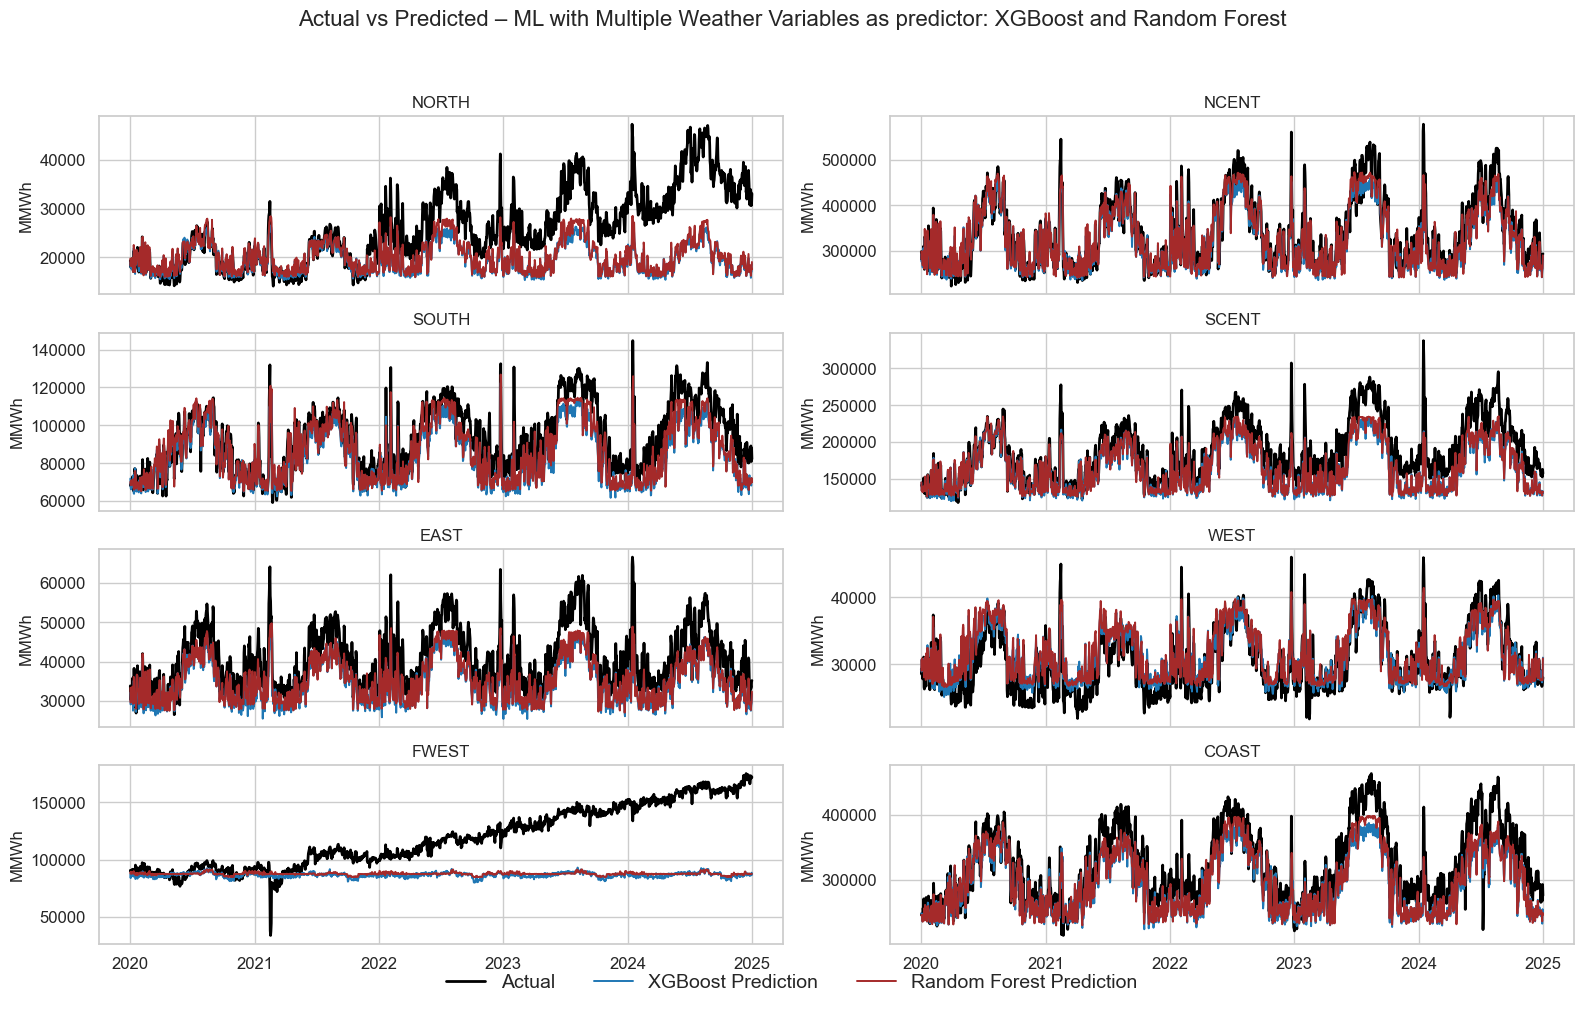

In [38]:
# Plotting ML Set 1: XGBoost and Random Forest - 8-Zone Panel
model_title_3 = "ML with Multiple Weather Variables as predictor: XGBoost and Random Forest"

fig, axes = plt.subplots(4, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for i, zone in enumerate(zone_list):

    # Actual load
    axes[i].plot(
        test.index,
        test[f"{zone}_Daily_Load_MW"],
        color="black",
        linewidth=2,
        label="Actual"
    )

    # XGBoost predictions
    axes[i].plot(
        test.index,
        ml2_predictions[zone],
        color="#1f77b4",
        linewidth=1.4,
        label="XGBoost Prediction"
    )
    
         # Random Forest predictions
    axes[i].plot(
        test.index,
        rf2_predictions[zone],
        color="brown",
        linewidth=1.4,
        label="Random Forest Prediction"
    )

    axes[i].set_title(zone)
    axes[i].set_ylabel("MMWh")
    axes[i].tick_params(axis='y', labelsize=12)

    # Year ticks on x-axis
    axes[i].xaxis.set_major_locator(mdates.YearLocator())
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    axes[i].tick_params(axis='x', labelsize=12)

# Unified Legend at Bottom
# Collect handles & labels from last axis
handles, labels = axes[-1].get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=3,
    fontsize=14,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

# Title and layout
plt.suptitle(f"Actual vs Predicted – {model_title_3}", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("ML2_Weather.png", dpi=300)
plt.show()
plt.close()

# Results - full comparison table

In [83]:
# First ensuring all DataFrames have the same index name
baseline1 = baseline1_metrics_df.copy()
hddcdd = hddcdd_metrics_df.copy()
ml1 = ml1_metrics_df.copy()
rf1 = rf1_metrics_df.copy()
ml2 = ml2_metrics_df.copy()
rf2 = rf2_metrics_df.copy()

# Renaming columns to avoid collisions during concatenation
baseline1.columns = [("Tmean", col) for col in baseline1.columns]
hddcdd.columns  = [("HDD_CDD_Linear", col) for col in hddcdd.columns]
ml1.columns     = [("XGB_HDD_CDD", col) for col in ml1.columns]
rf1.columns     = [("RF_HDD_CDD", col) for col in rf1.columns]
ml2.columns     = [("XGB_FullWeather", col) for col in ml2.columns]
rf2.columns     = [("RF_FullWeather", col) for col in rf2.columns]

# Combining everything into one master table
comparison_df = pd.concat(
    [baseline1, hddcdd, ml1, rf1, ml2, rf2],
    axis=1
)

# Optional: sorting columns to keep them ordered
comparison_df = comparison_df.sort_index(axis=1, level=0)

comparison_df

,"(HDD_CDD_Linear, MAE_Test)","(HDD_CDD_Linear, R2_Test)","(HDD_CDD_Linear, R2_Train)","(HDD_CDD_Linear, RMSE_Test)","(RF_FullWeather, MAE_Test)","(RF_FullWeather, R2_Test)","(RF_FullWeather, RMSE_Test)","(RF_HDD_CDD, MAE_Test)","(RF_HDD_CDD, R2_Test)","(RF_HDD_CDD, RMSE_Test)","(Tmean, MAE_Test)","(Tmean, R2_Test)","(Tmean, R2_Train)","(Tmean, RMSE_Test)","(XGB_FullWeather, MAE_Test)","(XGB_FullWeather, R2_Test)","(XGB_FullWeather, RMSE_Test)","(XGB_HDD_CDD, MAE_Test)","(XGB_HDD_CDD, R2_Test)","(XGB_HDD_CDD, RMSE_Test)"
Zone,,,,,,,,,,,,,,,,,,,,
NORTH,6146.948036,-0.163062,0.923727,8147.829011,6378.469197,-0.259845,8480.060114,6374.604307,-0.253112,8457.369745,6329.755066,-0.186282,0.641696,8228.760224,6703.600459,-0.400695,8941.536857,6652.218703,-0.372899,8852.371999
NCENT,15796.738842,0.920094,0.937963,20955.590928,17801.156134,0.900129,23427.717342,18267.597844,0.895663,23945.719502,35153.693997,0.644319,0.670549,44211.992024,19819.018309,0.873549,26361.553204,21518.432228,0.854043,28321.913445
SOUTH,4467.231469,0.884386,0.902951,5755.035679,7114.724365,0.736325,8691.150912,7054.867624,0.739294,8642.083682,7592.904727,0.660582,0.689611,9860.760357,8577.443832,0.628167,10320.888818,8822.616335,0.613068,10528.347803
SCENT,16001.765340,0.745216,0.934638,20069.430748,20545.845353,0.608685,24872.094344,20203.271582,0.619495,24526.141457,19272.670823,0.552672,0.709618,26592.673199,21720.884617,0.561980,26314.558949,21952.736704,0.556942,26465.438100
EAST,3756.506408,0.636771,0.902478,4542.535621,5079.254934,0.412846,5775.425077,4981.724509,0.431972,5680.583609,4249.350117,0.395307,0.633423,5861.053081,5692.718299,0.276565,6410.734108,6186.366373,0.168614,6872.414897
WEST,3581.664861,0.326284,0.873182,3908.494193,1885.609362,0.753610,2363.649686,1896.843965,0.746985,2395.215917,4165.516313,-0.021987,0.634939,4813.864320,1805.134285,0.769118,2288.053304,1742.261833,0.786316,2201.190324
FWEST,16747.510558,0.328771,0.897256,21813.293357,32364.856936,-1.399070,41238.931597,32605.068070,-1.422990,41444.006178,16749.822253,0.328264,0.880677,21821.535395,33299.354587,-1.485215,41972.797767,34462.364917,-1.604260,42966.317248
COAST,15085.083119,0.881173,0.941937,19698.358603,24927.169766,0.724776,29978.868337,25481.848858,0.707940,30882.218886,22049.166344,0.745643,0.788083,28819.988804,27555.057289,0.665598,33045.047195,30415.448515,0.605009,35914.148858


In [84]:
# saving to Excel: 
comparison_df.to_excel("ERCOT_LoadModel_Comparison.xlsx")

In [85]:
import os
os.getcwd()

'C:\\2. University of Oklahoma\\1. Optimization machine Learning and Data Mining\\Extreme\\3. Combined Data'